In [109]:
## Load libraries
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
plt.style.use('dark_background')
%matplotlib inline

In [110]:
## Mount Google drive folder if running in Colab
if('google.colab' in sys.modules):
    from google.colab import drive
    drive.mount('/content/drive', force_remount = True)
    DIR = '/content/drive/MyDrive/Colab Notebooks/MAHE/MSIS Coursework/EvenSem2024MAHE'
    DATA_DIR = DIR + '/Data/'
    os.chdir(DIR)
else:
    DATA_DIR = 'Data/'

In [111]:
## Load diabetes data
file = DATA_DIR+'houseprices_cleaned.csv'
df= pd.read_csv(file, header = 0)

print('House price dataset')
print('-----------')
print('Initial number of samples = %d'%(df.shape[0]))
print('Initial number of features = %d\n'%(df.shape[1]))
df.head(5)

House price dataset
-----------
Initial number of samples = 225
Initial number of features = 8



,locality,area,rent,price_per_sqft,facing,BHK,bathrooms,parking
0,BTM Layout,565.0,20060.0,6195.0,North-West,1,1,Bike
1,BTM Layout,1837.0,97434.0,9254.0,East,3,3,Bike and Car
2,BTM Layout,1280.0,54448.0,7422.0,East,2,2,Car
3,BTM Layout,2220.0,117000.0,9234.0,North,3,3,Bike and Car
4,BTM Layout,1113.0,34388.0,5391.0,East,2,2,Bike and Car


In [112]:
df.fillna(df.mean(), inplace=True)

C:\Users\ATISHAY SG\AppData\Local\Temp\ipykernel_7488\820435583.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.fillna(df.mean(), inplace=True)


In [130]:
## Create lists of ordinal, categorical, and continuous features
#categorical_features =  ['GENDER', 'BMILEVEL']
categorical_features =  ['locality', 'facing', 'parking']
continuous_features = df.drop(categorical_features, axis = 1).columns.tolist()

df[categorical_features] = df[categorical_features].fillna('NA')

# Convert categorical columns to categorical data type
df[categorical_features] = df[categorical_features].astype('category')


print(categorical_features)
print(continuous_features)

TypeError: Cannot setitem on a Categorical with a new category (NA), set the categories first

In [114]:
## Assign 'category' datatype to ordinal and categorical columns
print(df.dtypes)
df[categorical_features] = df[categorical_features].astype('category')
print('----')
df.dtypes

locality           object
area              float64
rent              float64
price_per_sqft    float64
facing             object
BHK                 int64
bathrooms           int64
parking            object
dtype: object
----


locality          category
area               float64
rent               float64
price_per_sqft     float64
facing            category
BHK                  int64
bathrooms            int64
parking           category
dtype: object

In [115]:
## Remove the target variable column from the list of continuous features
continuous_features.remove('price_per_sqft')

In [116]:
# Apply log transform on "area" and "rent" features
df['area'] = np.log(df['area'])
df['rent'] = np.log(df['rent'])

df['price_per_sqft'] = np.sqrt(df['price_per_sqft'])

In [117]:
X = df.drop('price_per_sqft', axis = 1)
# X = df
y = df['price_per_sqft']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

num_features = X_train.shape[1]
num_samples = X_train.shape[0]

print('House price dataset data set')
print('---------------------')
print('Number of training samples = %d'%(num_samples))
print('Number of features = %d'%(num_features))

House price dataset data set
---------------------
Number of training samples = 180
Number of features = 7


In [118]:
## Build pipeline for categorical and continuous features

# Pipeline object for categorical (features
categorical_transformer = Pipeline(steps = [('onehotenc', OneHotEncoder(handle_unknown = 'ignore'))])

# Pipeline object for continuous features
continuous_transformer = Pipeline(steps = [('scaler', RobustScaler())])

# Create a preprocessor object for all features
preprocessor = ColumnTransformer(transformers = [('continuous', continuous_transformer, continuous_features),
                                                 ('categorical', categorical_transformer, categorical_features)
                                                ],
                                                remainder = 'passthrough')

In [119]:
## Fit and transform train data using preprocessor
X_train_transformed = preprocessor.fit_transform(X_train).T
# Update number of features
num_features = X_train_transformed.shape[0]
# Transform training data using preprocessor
X_test_transformed = preprocessor.transform(X_test).T
# Convert Y_train and Y_test to numpy arrays
# Y_train = Y_train.to_numpy()
# Y_test = Y_test.to_numpy()

In [120]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model
model_linear = LinearRegression()

# Fit the model to the data
model_linear.fit(X_train_transformed.T, Y_train)

# Predict the target variable for the test data
y_pred = model_linear.predict(X_test_transformed.T)


In [121]:
from sklearn.metrics import mean_squared_error

# Calculate the mean squared error for the test data
mse_linear = mean_squared_error(Y_test, y_pred)
mse_linear


4.607001716682083

C:\Users\ATISHAY SG\AppData\Local\Temp\ipykernel_7488\3435677552.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'k--', lw=2, color = 'red')  # Plotting the diagonal line for reference


Text(0.5, 1.0, 'Actual vs Predicted Price per Sqft (Linear Regression)')

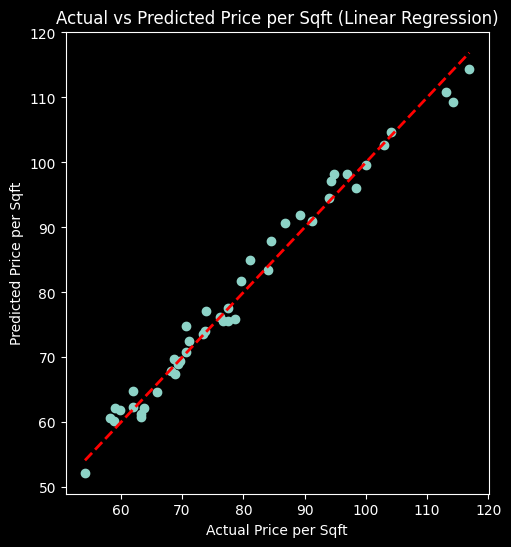

In [122]:
# Plot for Linear Regression model
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(Y_test, y_pred)
plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)], 'k--', lw=2, color = 'red')  # Plotting the diagonal line for reference
plt.xlabel('Actual Price per Sqft')
plt.ylabel('Predicted Price per Sqft')
plt.title('Actual vs Predicted Price per Sqft (Linear Regression)')


In [123]:
df.head(5)

,locality,area,rent,price_per_sqft,facing,BHK,bathrooms,parking
0,BTM Layout,6.336826,9.906483,78.708322,North-West,1,1,Bike
1,BTM Layout,7.515889,11.486931,96.197713,East,3,3,Bike and Car
2,BTM Layout,7.154615,10.905001,86.151030,East,2,2,Car
3,BTM Layout,7.705262,11.669929,96.093704,North,3,3,Bike and Car
4,BTM Layout,7.014814,10.445463,73.423430,East,2,2,Bike and Car


In [129]:
# Lists to store MSE values and epochs
mse_values = []
epochs = []

# Train the model and compute MSE for each epoch
for epoch in range(1, 101):  # 100 epochs for demonstration
    model_linear.fit(X, y)
    y_pred = model_linear.predict(X)
    mse = mean_squared_error(y, y_pred)
    mse_values.append(mse)
    epochs.append(epoch)


ValueError: Input contains NaN

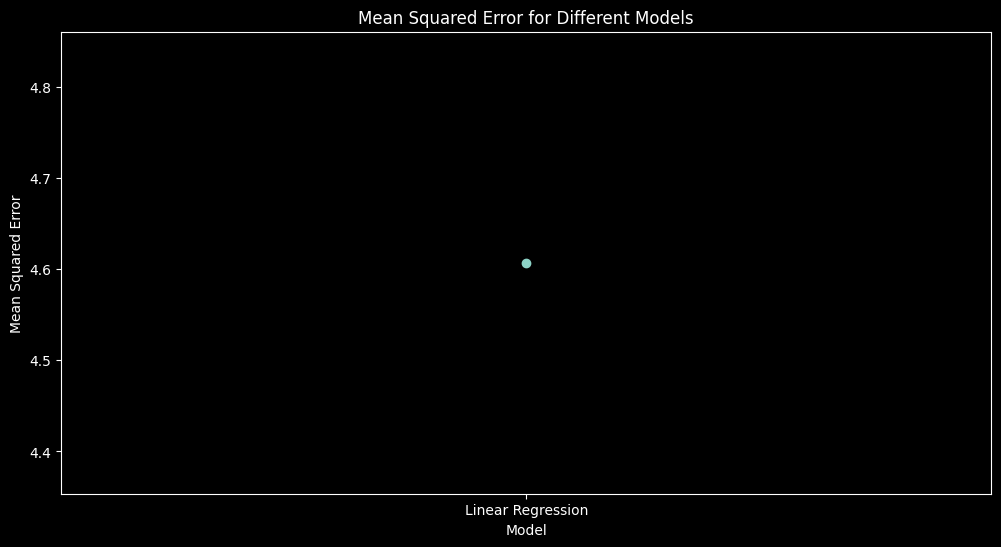

In [128]:
# Create a list to store the mean squared error values
mse_values = []

# Add the mean squared error for each model to the list
mse_values.append(mse_linear)
# Plot the scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(['Linear Regression'], mse_values)
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.title('Mean Squared Error for Different Models')
plt.show()
